In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from typing import List, Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

# Set global plotting parameters
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10



Problem 1: Rastrigin Function Implementation and Testing
Testing Rastrigin function on sample points:
Point                    | f(x1, x2)
---------------------------------------------
[  0.0,   0.0]           |   0.0000
[  1.0,   1.0]           |   2.0000
[ -1.0,  -1.0]           |   2.0000
[  2.5,  -1.5]           |  48.5000
[  5.0,   5.0]           |  50.0000
[  0.5,  -0.3]           |  33.4302

Global minimum: f(0,0) = 0.0000

Generating 2D visualization of the Rastrigin function...


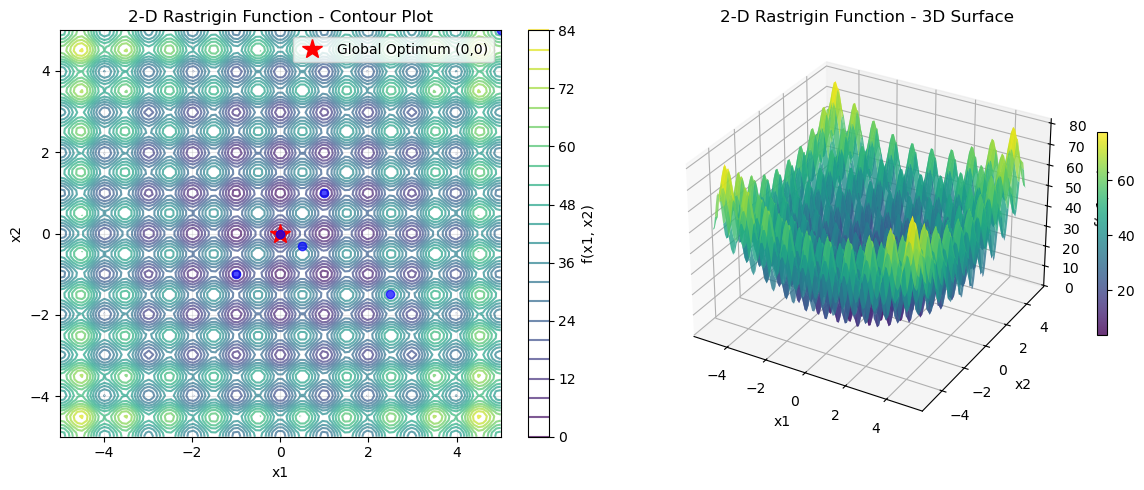

Problem 1 completed successfully!


In [ ]:
#  Problem 1: Implement the Rastrigin function in Python and test it on sample points
def rastrigin_2d(x1, x2, A=10):
    """
    2-D Rastrigin function implementation
    f(x1, x2) = A*n + sum(xi^2 - A*cos(2*pi*xi))
    where n=2 for 2D case, A=10 (default)
    Global minimum is at (0,0) with f(0,0) = 0
    Search domain: [-5.12, 5.12] for each variable
    """
    n = 2
    return A * n + (x1**2 - A * np.cos(2 * np.pi * x1)) + (x2**2 - A * np.cos(2 * np.pi * x2))

def rastrigin_vector(x, A=10):
    """Vector version of Rastrigin function for convenience"""
    return rastrigin_2d(x[0], x[1], A)

print("Problem 1: Rastrigin Function Implementation and Testing")
print("=" * 60)

# Test the function on various sample points
test_points = [
    [0.0, 0.0],      # Global optimum - should give f(x) = 0
    [1.0, 1.0],      # Simple test point
    [-1.0, -1.0],    # Negative coordinates
    [2.5, -1.5],     # Mixed coordinates
    [5.0, 5.0],      # Near boundary of search domain
    [0.5, -0.3]      # Small values near optimum
]

print("Testing Rastrigin function on sample points:")
print("Point                    | f(x1, x2)")
print("-" * 45)
for i, point in enumerate(test_points):
    fitness = rastrigin_vector(point)
    print(f"[{point[0]:5.1f}, {point[1]:5.1f}]           | {fitness:8.4f}")

print(f"\nGlobal minimum: f(0,0) = {rastrigin_2d(0,0):.4f}")

# Create visualization of the Rastrigin function
print("\nGenerating 2D visualization of the Rastrigin function...")
x1_range = np.linspace(-5, 5, 100)
x2_range = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = rastrigin_2d(X1, X2)

plt.figure(figsize=(12, 5))

# Contour plot
plt.subplot(1, 2, 1)
contour = plt.contour(X1, X2, Z, levels=25, alpha=0.7)
plt.colorbar(contour, label='f(x1, x2)')
plt.title('2-D Rastrigin Function - Contour Plot')
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(0, 0, 'r*', markersize=15, label='Global Optimum (0,0)')
# Plot test points
for point in test_points:
    plt.plot(point[0], point[1], 'bo', markersize=6, alpha=0.7)
plt.legend()
plt.grid(True, alpha=0.3)

# 3D surface plot
ax = plt.subplot(1, 2, 2, projection='3d')
surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax.set_title('2-D Rastrigin Function - 3D Surface')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')
plt.colorbar(surf, shrink=0.5)

plt.tight_layout()
plt.show()

print("Problem 1 completed successfully!")

Problem 2: Simple (μ, λ)-ES with Shared Sigma and 1/5 Success Rule
Testing (5, 20)-ES with 5 independent runs:
Run | Best Fitness | Solution (x1, x2)     | Final Sigma
------------------------------------------------------------
  1 |    3.913128 | [ 0.964,  1.090] |   2.0000
  2 |    4.966861 | [-0.137, -0.946] |   2.0000
  3 |   12.753593 | [ 2.112, -0.182] |   2.0000
  4 |    2.330177 | [-1.024, -0.965] |   2.0000
  5 |    2.318540 | [ 0.964,  0.077] |   2.0000

Statistical Summary:
Mean best fitness: 5.256460
Std deviation:     3.880462
Best overall:      2.318540
Worst overall:     12.753593


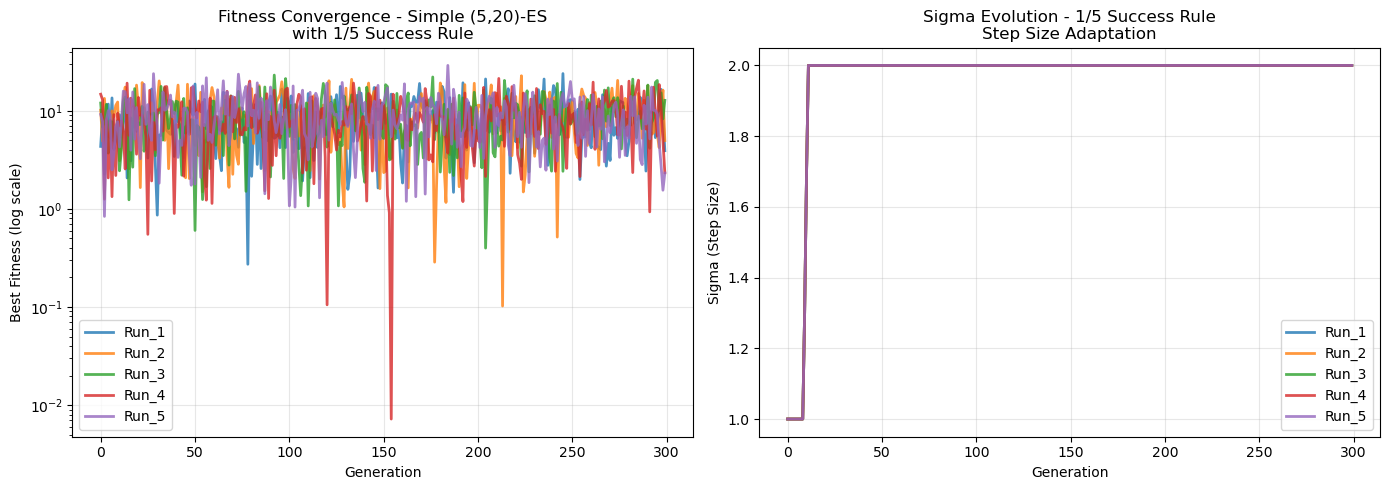

Problem 2 completed successfully!


In [23]:
# Problem 2: Implement a simple (μ, λ)-Evolution Strategy with shared sigma and 1/5 success rule


import numpy as np
import matplotlib.pyplot as plt

class SimpleES:
    """
    Simple (μ, λ)-Evolution Strategy with:
    - Shared sigma for all variables
    - 1/5 success rule for sigma adaptation
    - (μ, λ) selection (only offspring survive)
    """
    def __init__(self, mu, lambda_val, sigma_init=1.0, bounds=(-5.12, 5.12)):
        self.mu = mu                           # Number of parents
        self.lambda_val = lambda_val           # Number of offspring
        self.sigma = sigma_init                # Mutation step size (shared)
        self.bounds = bounds                   # Search space bounds
        self.success_rate_window = 10          # Window size for 1/5 rule
        self.successes = []                    # Track successes for 1/5 rule
        
    def initialize_population(self):
        """Initialize μ random individuals within bounds"""
        population = []
        for _ in range(self.mu):
            individual = np.random.uniform(self.bounds[0], self.bounds[1], 2)
            fitness = rastrigin_vector(individual)
            population.append((individual.copy(), fitness))
        # Sort by fitness (best first)
        return sorted(population, key=lambda x: x[1])
    
    def mutate(self, parent):
        """Apply Gaussian mutation with shared sigma"""
        child = parent + np.random.normal(0, self.sigma, 2)
        # Ensure child stays within bounds
        child = np.clip(child, self.bounds[0], self.bounds[1])
        return child
    
    def update_sigma_1_5_rule(self):
        """Update sigma using 1/5 success rule"""
        if len(self.successes) >= self.success_rate_window:
            recent_success_rate = np.mean(self.successes[-self.success_rate_window:])
            
            if recent_success_rate > 1/5:
                self.sigma *= 1.3      # Increase step size (more exploration)
            elif recent_success_rate < 1/5:
                self.sigma *= 0.8      # Decrease step size (more exploitation)
            # If success rate ≈ 1/5, keep sigma unchanged
            
            # Keep sigma within reasonable bounds
            self.sigma = np.clip(self.sigma, 0.001, 2.0)
    
    def run(self, generations=500, verbose=False):
        """Execute the ES algorithm"""
        # Initialize population
        population = self.initialize_population()
        
        # Track evolution progress
        fitness_history = []
        sigma_history = []
        
        for gen in range(generations):
            # Store parent fitness values for success tracking
            parent_fitness_values = [ind[1] for ind in population]
            
            # Generate λ offspring
            offspring = []
            for _ in range(self.lambda_val):
                # Select random parent (uniform selection)
                parent_idx = np.random.randint(0, self.mu)
                parent = population[parent_idx][0]
                
                # Create mutated offspring
                child = self.mutate(parent)
                child_fitness = rastrigin_vector(child)
                offspring.append((child, child_fitness))
            
            # (μ, λ) Selection: select best μ from λ offspring only
            offspring.sort(key=lambda x: x[1])
            new_population = offspring[:self.mu]
            
            # Track success for 1/5 rule: compare best offspring with worst parent
            best_offspring_fitness = offspring[0][1]
            worst_parent_fitness = max(parent_fitness_values)
            success = 1 if best_offspring_fitness < worst_parent_fitness else 0
            self.successes.append(success)
            
            # Apply 1/5 success rule to adapt sigma
            self.update_sigma_1_5_rule()
            
            # Update population
            population = new_population
            
            # Record progress
            best_fitness = population[0][1]
            fitness_history.append(best_fitness)
            sigma_history.append(self.sigma)
            
            if verbose and gen % 50 == 0:
                print(f"Generation {gen:3d}: Best fitness = {best_fitness:8.6f}, Sigma = {self.sigma:.4f}")
        
        # Return best solution and evolution history
        best_individual, best_fitness = population[0]
        return (best_individual, best_fitness), fitness_history, sigma_history

print("Problem 2: Simple (μ, λ)-ES with Shared Sigma and 1/5 Success Rule")
print("=" * 70)

# Set random seed for reproducible results
np.random.seed(42)

# Test the simple ES with multiple independent runs
print("Testing (5, 20)-ES with 5 independent runs:")
print("Run | Best Fitness | Solution (x1, x2)     | Final Sigma")
print("-" * 60)

results_problem2 = {}
num_runs = 5

for run_id in range(num_runs):
    # Set different seed for each run
    np.random.seed(run_id * 100)
    
    # Create and run ES
    es = SimpleES(mu=5, lambda_val=20, sigma_init=1.0)
    (best_solution, best_fitness), fitness_history, sigma_history = es.run(generations=300)
    
    # Store results
    results_problem2[f'Run_{run_id+1}'] = {
        'best_solution': best_solution,
        'best_fitness': best_fitness,
        'fitness_history': fitness_history,
        'sigma_history': sigma_history,
        'final_sigma': sigma_history[-1]
    }
    
    print(f"{run_id+1:3d} | {best_fitness:11.6f} | [{best_solution[0]:6.3f}, {best_solution[1]:6.3f}] | {sigma_history[-1]:8.4f}")

# Statistical summary
all_best_fitness = [data['best_fitness'] for data in results_problem2.values()]
print(f"\nStatistical Summary:")
print(f"Mean best fitness: {np.mean(all_best_fitness):8.6f}")
print(f"Std deviation:     {np.std(all_best_fitness):8.6f}")
print(f"Best overall:      {np.min(all_best_fitness):8.6f}")
print(f"Worst overall:     {np.max(all_best_fitness):8.6f}")

# Visualization of convergence
plt.figure(figsize=(14, 5))

# Plot fitness convergence
plt.subplot(1, 2, 1)
for run_name, data in results_problem2.items():
    plt.semilogy(data['fitness_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Fitness Convergence - Simple (5,20)-ES\nwith 1/5 Success Rule')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot sigma evolution
plt.subplot(1, 2, 2)
for run_name, data in results_problem2.items():
    plt.plot(data['sigma_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Sigma Evolution - 1/5 Success Rule\nStep Size Adaptation')
plt.xlabel('Generation')
plt.ylabel('Sigma (Step Size)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Problem 2 completed successfully!")

Problem 3: Comparing Different μ:λ Ratios
Comparing ES configurations:
  (1,7)-ES: μ=1, λ=7, selection pressure (λ/μ) = 7.0
  (5,20)-ES: μ=5, λ=20, selection pressure (λ/μ) = 4.0
  (10,30)-ES: μ=10, λ=30, selection pressure (λ/μ) = 3.0

Running experiments (3 runs per configuration)...

Testing (1,7)-ES:
Run | Best Fitness | Solution (x1, x2)
----------------------------------------
  1 |   10.567993 | [ 0.827, -1.936]
  2 |    2.322840 | [-0.970,  0.079]
  3 |   24.656324 | [-1.039, -2.641]

Testing (5,20)-ES:
Run | Best Fitness | Solution (x1, x2)
----------------------------------------
  1 |    0.964340 | [ 0.034, -0.061]
  2 |    3.116347 | [-1.015,  1.068]
  3 |    1.483607 | [ 0.027,  1.037]

Testing (10,30)-ES:
Run | Best Fitness | Solution (x1, x2)
----------------------------------------
  1 |    7.216740 | [-1.894, -0.945]
  2 |    3.551501 | [ 1.078, -0.962]
  3 |   12.085966 | [-0.968, -0.264]

Generating performance comparison plots...


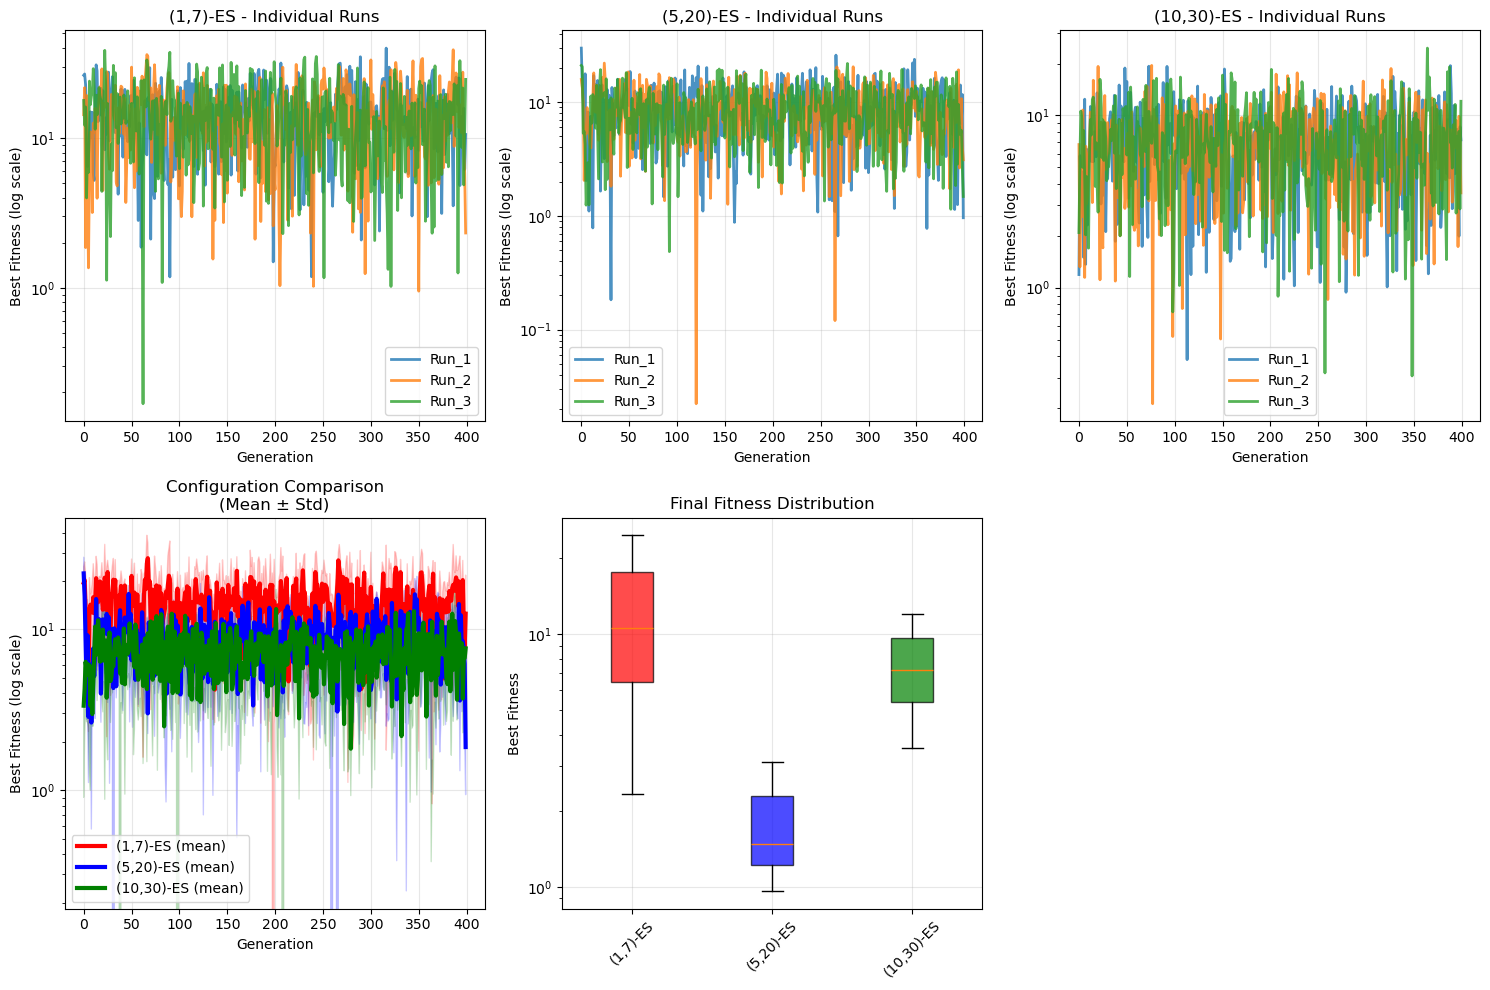


Statistical Performance Analysis:
Configuration    | Mean ± Std        | Best      | Worst     
-----------------------------------------------------------------
(1,7)-ES        | 12.515719 ± 9.221039 | 2.322840 | 24.656324
(5,20)-ES       | 1.854764 ± 0.916916 | 0.964340 | 3.116347
(10,30)-ES      | 7.618069 ± 3.495718 | 3.551501 | 12.085966
Problem 3 completed successfully!


In [25]:
# Problem 3: Experiment with three different μ:λ ratios and compare performance

print("Problem 3: Comparing Different μ:λ Ratios")
print("=" * 45)

# Define different ES configurations to compare
es_configurations = [
    (1, 7, "(1,7)-ES"),      # Small population, high selection pressure
    (5, 20, "(5,20)-ES"),    # Medium population, moderate selection pressure  
    (10, 30, "(10,30)-ES")   # Larger population, lower selection pressure
]

print("Comparing ES configurations:")
for mu, lam, name in es_configurations:
    ratio = lam / mu
    print(f"  {name}: μ={mu}, λ={lam}, selection pressure (λ/μ) = {ratio:.1f}")

print("\nRunning experiments (3 runs per configuration)...")

results_problem3 = {}

for mu, lambda_val, config_name in es_configurations:
    print(f"\nTesting {config_name}:")
    print(f"Run | Best Fitness | Solution (x1, x2)")
    print("-" * 40)
    
    config_results = {}
    
    # Run multiple independent trials for each configuration
    for run_id in range(3):
        # Set unique seed for fair comparison
        np.random.seed((hash(config_name) % 1000) + run_id * 50)
        
        # Create and run ES with current configuration
        es = SimpleES(mu=mu, lambda_val=lambda_val, sigma_init=1.0)
        (best_solution, best_fitness), fitness_history, sigma_history = es.run(generations=400)
        
        # Store results
        config_results[f'Run_{run_id+1}'] = {
            'best_solution': best_solution,
            'best_fitness': best_fitness,
            'fitness_history': fitness_history,
            'sigma_history': sigma_history
        }
        
        print(f"{run_id+1:3d} | {best_fitness:11.6f} | [{best_solution[0]:6.3f}, {best_solution[1]:6.3f}]")
    
    results_problem3[config_name] = config_results

# Performance comparison visualization
print("\nGenerating performance comparison plots...")

plt.figure(figsize=(15, 10))

# Individual convergence plots for each configuration
for i, (config_name, config_results) in enumerate(results_problem3.items()):
    plt.subplot(2, 3, i+1)
    
    for run_name, data in config_results.items():
        plt.semilogy(data['fitness_history'], alpha=0.8, linewidth=2, label=run_name)
    
    plt.title(f'{config_name} - Individual Runs')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness (log scale)')
    plt.legend()
    plt.grid(True, alpha=0.3)

# Combined comparison plot
plt.subplot(2, 3, 4)
colors = ['red', 'blue', 'green']
for i, (config_name, config_results) in enumerate(results_problem3.items()):
    # Plot mean convergence with confidence intervals
    all_histories = [data['fitness_history'] for data in config_results.values()]
    mean_history = np.mean(all_histories, axis=0)
    std_history = np.std(all_histories, axis=0)
    
    generations = range(len(mean_history))
    plt.semilogy(generations, mean_history, color=colors[i], linewidth=3, label=f'{config_name} (mean)')
    plt.fill_between(generations, 
                     mean_history - std_history, 
                     mean_history + std_history, 
                     color=colors[i], alpha=0.2)

plt.title('Configuration Comparison\n(Mean ± Std)')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot comparison of final results
plt.subplot(2, 3, 5)
final_fitness_data = []
config_labels = []

for config_name, config_results in results_problem3.items():
    final_fitnesses = [data['best_fitness'] for data in config_results.values()]
    final_fitness_data.append(final_fitnesses)
    config_labels.append(config_name)

box_plot = plt.boxplot(final_fitness_data, labels=config_labels, patch_artist=True)
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Final Fitness Distribution')
plt.ylabel('Best Fitness')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis
print("\nStatistical Performance Analysis:")
print("=" * 50)
print("Configuration    | Mean ± Std        | Best      | Worst     ")
print("-" * 65)

for config_name, config_results in results_problem3.items():
    final_fitnesses = [data['best_fitness'] for data in config_results.values()]
    mean_fitness = np.mean(final_fitnesses)
    std_fitness = np.std(final_fitnesses)
    best_fitness = np.min(final_fitnesses)
    worst_fitness = np.max(final_fitnesses)
    
    print(f"{config_name:15s} | {mean_fitness:.6f} ± {std_fitness:.6f} | {best_fitness:.6f} | {worst_fitness:.6f}")

print("Problem 3 completed successfully!")

Problem 4: ES with Individual Sigma Values per Variable
Testing Individual Sigma ES (5, 20) with 3 independent runs:
Run | Best Fitness | Solution (x1, x2)     | Final Sigmas (σ1, σ2)
----------------------------------------------------------------------
  1 |    0.994966 | [-0.000, -0.995] | [0.001, 0.003]
  2 |    0.995047 | [ 0.000, -0.996] | [0.001, 0.001]
  3 |    0.995044 | [-0.001, -0.995] | [0.002, 0.002]

Performance Summary:
Mean best fitness: 0.995019
Std deviation:     0.000038
Best overall:      0.994966


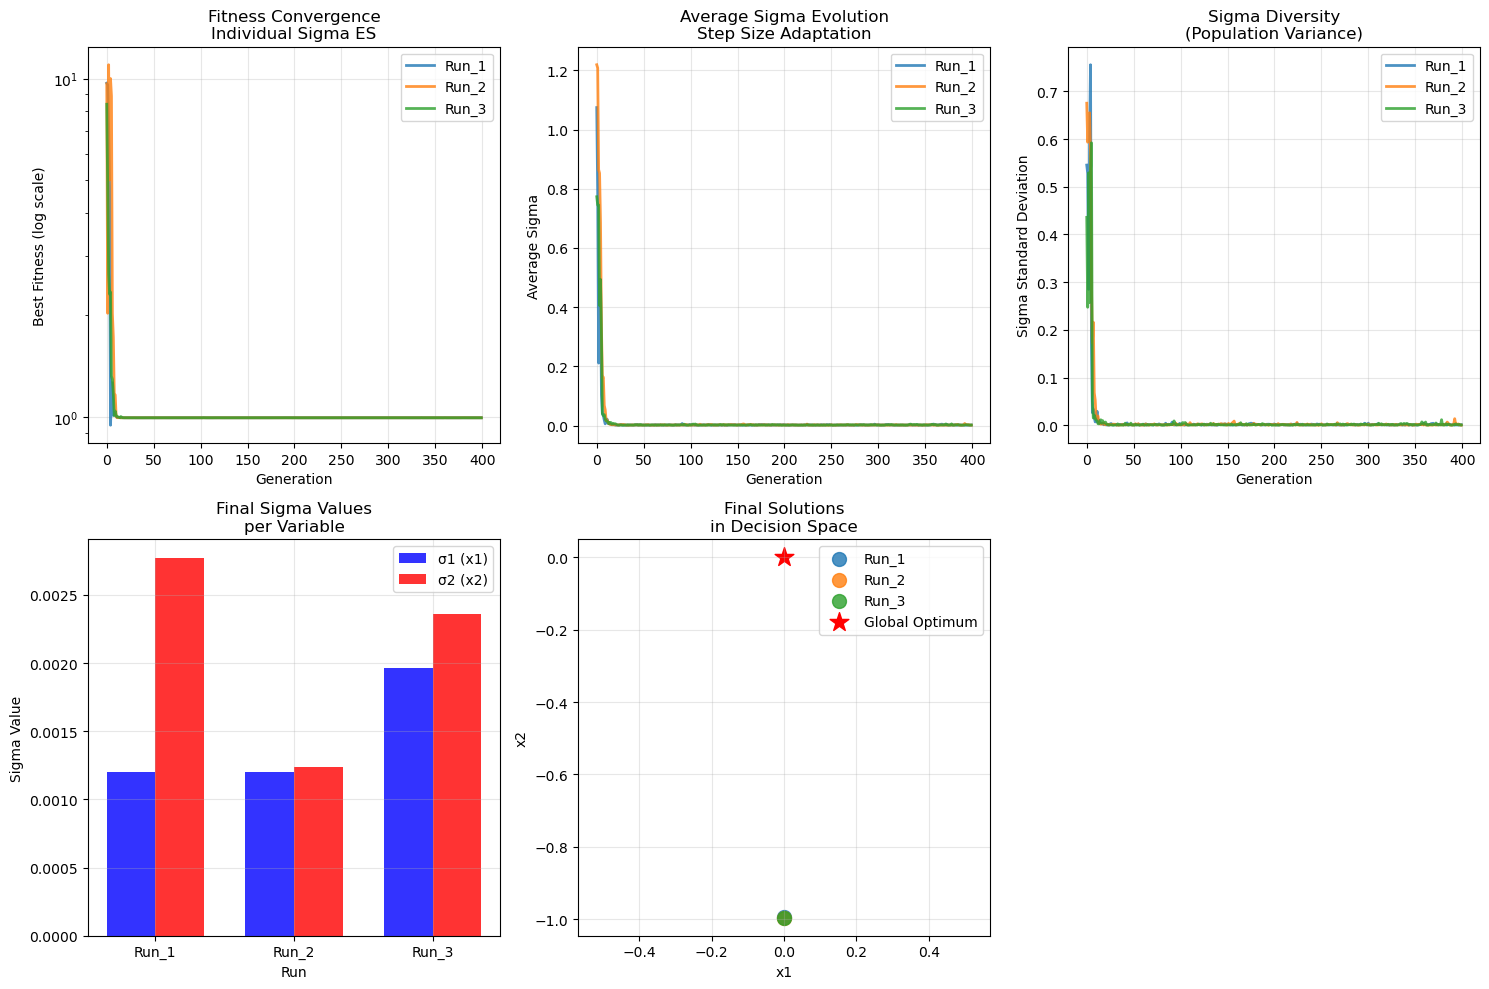

Problem 4 completed successfully!


In [27]:
# Problem 4: Modify ES to use individual sigma values per variable with 1/5 rule


import numpy as np
import matplotlib.pyplot as plt

class IndividualSigmaES:
    """
    Evolution Strategy with individual sigma values for each variable
    - Each variable has its own mutation step size
    - 1/5 success rule applied to adapt sigmas
    - Self-adaptation using log-normal update rule
    """
    def __init__(self, mu, lambda_val, sigma_init=1.0, bounds=(-5.12, 5.12)):
        self.mu = mu
        self.lambda_val = lambda_val
        self.bounds = bounds
        self.sigma_init = sigma_init
        self.success_rate_window = 10
        self.successes = []
        
        # Learning parameters for sigma self-adaptation
        self.tau = 1.0 / np.sqrt(2 * np.sqrt(2))    # Individual learning rate
        self.tau0 = 1.0 / np.sqrt(2 * 2)            # Global learning rate
        
    def initialize_population(self):
        """Initialize population with individual sigmas for each variable"""
        population = []
        for _ in range(self.mu):
            # Random individual in search space
            individual = np.random.uniform(self.bounds[0], self.bounds[1], 2)
            # Individual sigma for each dimension
            sigmas = np.full(2, self.sigma_init)
            fitness = rastrigin_vector(individual)
            population.append((individual.copy(), sigmas.copy(), fitness))
        
        return sorted(population, key=lambda x: x[2])  # Sort by fitness
    
    def mutate_individual(self, parent, parent_sigmas):
        """
        Mutate individual using individual sigmas with self-adaptation
        1. First mutate the sigmas (strategy parameters)
        2. Then mutate the individual using the new sigmas
        """
        # Step 1: Self-adapt sigmas using log-normal distribution
        global_factor = self.tau0 * np.random.normal()  # Common random factor
        individual_factors = self.tau * np.random.normal(size=2)  # Individual factors
        
        new_sigmas = parent_sigmas * np.exp(global_factor + individual_factors)
        
        # Keep sigmas within reasonable bounds
        new_sigmas = np.clip(new_sigmas, 0.001, 2.0)
        
        # Step 2: Mutate the individual using new sigmas
        mutations = np.random.normal(0, new_sigmas, 2)
        child = parent + mutations
        
        # Apply boundary constraints
        child = np.clip(child, self.bounds[0], self.bounds[1])
        
        return child, new_sigmas
    
    def apply_1_5_rule_to_population(self, population):
        """Apply 1/5 success rule to adapt sigmas across the population"""
        if len(self.successes) >= self.success_rate_window:
            success_rate = np.mean(self.successes[-self.success_rate_window:])
            
            # Determine adaptation factor
            if success_rate > 1/5:
                factor = 1.2  # Increase step sizes
            elif success_rate < 1/5:
                factor = 0.85  # Decrease step sizes
            else:
                factor = 1.0  # No change
            
            # Apply factor to all individuals' sigmas
            for i in range(len(population)):
                individual, sigmas, fitness = population[i]
                adapted_sigmas = sigmas * factor
                adapted_sigmas = np.clip(adapted_sigmas, 0.001, 2.0)
                population[i] = (individual, adapted_sigmas, fitness)
    
    def run(self, generations=500, verbose=False):
        """Execute the ES with individual sigmas"""
        # Initialize population
        population = self.initialize_population()
        
        # Evolution tracking
        fitness_history = []
        avg_sigma_history = []
        sigma_diversity_history = []
        
        for gen in range(generations):
            # Store parent fitnesses for success tracking
            parent_fitnesses = [ind[2] for ind in population]
            
            # Generate lambda offspring
            offspring = []
            for _ in range(self.lambda_val):
                # Select random parent
                parent_idx = np.random.randint(0, self.mu)
                parent, parent_sigmas, _ = population[parent_idx]
                
                # Create mutated offspring
                child, child_sigmas = self.mutate_individual(parent, parent_sigmas)
                child_fitness = rastrigin_vector(child)
                offspring.append((child, child_sigmas, child_fitness))
            
            # (μ, λ) Selection
            offspring.sort(key=lambda x: x[2])
            new_population = offspring[:self.mu]
            
            # Track success for 1/5 rule
            best_offspring_fitness = offspring[0][2]
            worst_parent_fitness = max(parent_fitnesses)
            success = 1 if best_offspring_fitness < worst_parent_fitness else 0
            self.successes.append(success)
            
            # Apply 1/5 rule to adapt sigmas
            self.apply_1_5_rule_to_population(new_population)
            
            population = new_population
            
            # Record evolution statistics
            best_fitness = population[0][2]
            fitness_history.append(best_fitness)
            
            # Calculate sigma statistics
            all_sigmas = np.array([ind[1] for ind in population])
            avg_sigma = np.mean(all_sigmas)
            sigma_diversity = np.std(all_sigmas)
            
            avg_sigma_history.append(avg_sigma)
            sigma_diversity_history.append(sigma_diversity)
            
            if verbose and gen % 50 == 0:
                print(f"Gen {gen:3d}: Best fitness = {best_fitness:8.6f}, "
                      f"Avg sigma = {avg_sigma:.4f}, Sigma diversity = {sigma_diversity:.4f}")
        
        best_individual, best_sigmas, best_fitness = population[0]
        return ((best_individual, best_sigmas, best_fitness), 
                fitness_history, avg_sigma_history, sigma_diversity_history)

print("Problem 4: ES with Individual Sigma Values per Variable")
print("=" * 55)

# Test individual sigma ES with multiple runs
print("Testing Individual Sigma ES (5, 20) with 3 independent runs:")
print("Run | Best Fitness | Solution (x1, x2)     | Final Sigmas (σ1, σ2)")
print("-" * 70)

results_problem4 = {}

for run_id in range(3):
    # Set unique seed for each run
    np.random.seed(run_id * 200 + 100)
    
    # Create and run Individual Sigma ES
    es = IndividualSigmaES(mu=5, lambda_val=20, sigma_init=1.0)
    ((best_solution, best_sigmas, best_fitness), 
     fitness_history, sigma_history, diversity_history) = es.run(generations=400, verbose=False)
    
    # Store results
    results_problem4[f'Run_{run_id+1}'] = {
        'best_solution': best_solution,
        'best_sigmas': best_sigmas,
        'best_fitness': best_fitness,
        'fitness_history': fitness_history,
        'avg_sigma_history': sigma_history,
        'sigma_diversity_history': diversity_history
    }
    
    print(f"{run_id+1:3d} | {best_fitness:11.6f} | [{best_solution[0]:6.3f}, {best_solution[1]:6.3f}] | "
          f"[{best_sigmas[0]:5.3f}, {best_sigmas[1]:5.3f}]")

# Performance analysis
all_best_fitness = [data['best_fitness'] for data in results_problem4.values()]
print(f"\nPerformance Summary:")
print(f"Mean best fitness: {np.mean(all_best_fitness):8.6f}")
print(f"Std deviation:     {np.std(all_best_fitness):8.6f}")
print(f"Best overall:      {np.min(all_best_fitness):8.6f}")

# Visualization
plt.figure(figsize=(15, 10))

# Fitness convergence
plt.subplot(2, 3, 1)
for run_name, data in results_problem4.items():
    plt.semilogy(data['fitness_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Fitness Convergence\nIndividual Sigma ES')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)

# Average sigma evolution
plt.subplot(2, 3, 2)
for run_name, data in results_problem4.items():
    plt.plot(data['avg_sigma_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Average Sigma Evolution\nStep Size Adaptation')
plt.xlabel('Generation')
plt.ylabel('Average Sigma')
plt.legend()
plt.grid(True, alpha=0.3)

# Sigma diversity
plt.subplot(2, 3, 3)
for run_name, data in results_problem4.items():
    plt.plot(data['sigma_diversity_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Sigma Diversity\n(Population Variance)')
plt.xlabel('Generation')
plt.ylabel('Sigma Standard Deviation')
plt.legend()
plt.grid(True, alpha=0.3)

# Final sigma values visualization
plt.subplot(2, 3, 4)
run_names = list(results_problem4.keys())
sigma1_values = [results_problem4[run]['best_sigmas'][0] for run in run_names]
sigma2_values = [results_problem4[run]['best_sigmas'][1] for run in run_names]

x_pos = np.arange(len(run_names))
width = 0.35

plt.bar(x_pos - width/2, sigma1_values, width, label='σ1 (x1)', alpha=0.8, color='blue')
plt.bar(x_pos + width/2, sigma2_values, width, label='σ2 (x2)', alpha=0.8, color='red')

plt.title('Final Sigma Values\nper Variable')
plt.xlabel('Run')
plt.ylabel('Sigma Value')
plt.xticks(x_pos, run_names)
plt.legend()
plt.grid(True, alpha=0.3)

# Solution space visualization
plt.subplot(2, 3, 5)
for run_name, data in results_problem4.items():
    solution = data['best_solution']
    plt.scatter(solution[0], solution[1], s=100, alpha=0.8, label=run_name)

plt.scatter(0, 0, s=200, c='red', marker='*', label='Global Optimum')
plt.title('Final Solutions\nin Decision Space')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

print("Problem 4 completed successfully!")

Problem 5: ES with Global Intermediate Recombination on Sigma
Global Intermediate Recombination Strategy:
- Sigma values: σ_new = mean(σ_parent1, σ_parent2, ..., σ_parentμ)
- Applied before each mutation operation
- Promotes convergence of step sizes across population

Testing Global Intermediate Recombination ES (5, 20) with 3 runs:
Run | Best Fitness | Solution (x1, x2)     | Final Sigmas (σ1, σ2)
----------------------------------------------------------------------
  1 |    0.995077 | [ 0.996, -0.000] | [0.001, 0.001]
  2 |    0.995235 | [ 0.001,  0.995] | [0.001, 0.001]
  3 |    1.989969 | [-0.995,  0.995] | [0.001, 0.001]

Performance Summary:
Mean best fitness: 1.326760
Best overall:      0.995077


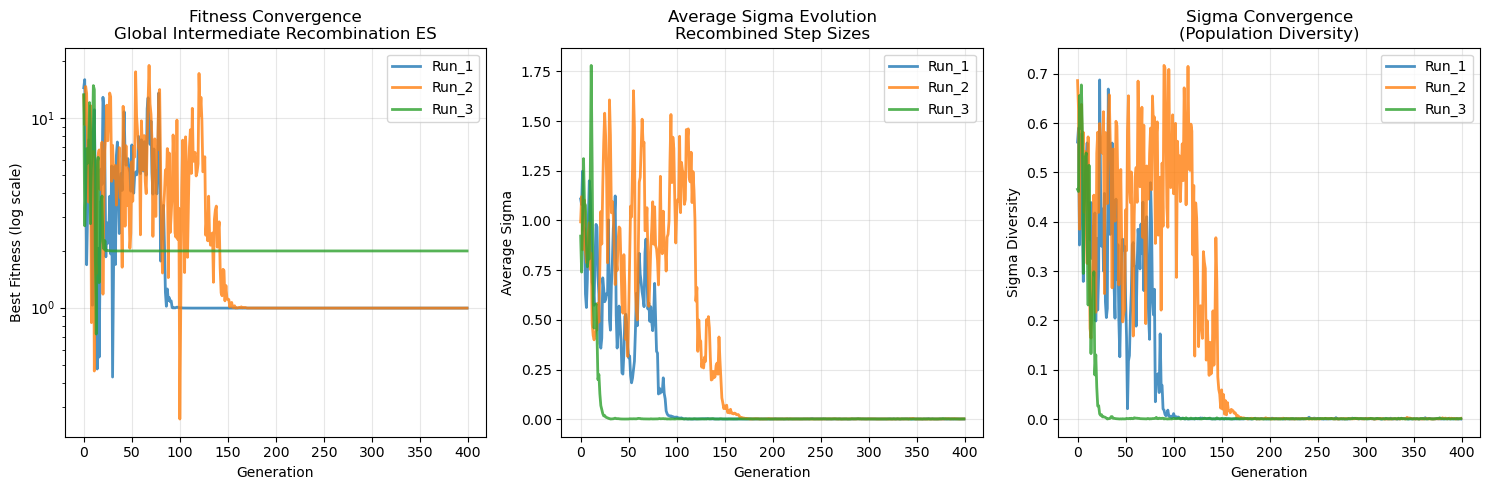

Problem 5 completed successfully!


In [29]:
# Problem 5: Extend ES with global intermediate recombination on sigma values

class GlobalRecombinationES:
    """
    Evolution Strategy with Global Intermediate Recombination on Sigma
    - Individual sigma values per variable
    - Global intermediate recombination: new sigma = mean of all parent sigmas
    - Self-adaptation with recombined sigma values
    """
    def __init__(self, mu, lambda_val, sigma_init=1.0, bounds=(-5.12, 5.12)):
        self.mu = mu
        self.lambda_val = lambda_val
        self.bounds = bounds
        self.sigma_init = sigma_init
        
        # Self-adaptation parameters
        self.tau = 1.0 / np.sqrt(2 * np.sqrt(2))
        self.tau0 = 1.0 / np.sqrt(2 * 2)
        
    def initialize_population(self):
        """Initialize population with individual sigmas"""
        population = []
        for _ in range(self.mu):
            individual = np.random.uniform(self.bounds[0], self.bounds[1], 2)
            sigmas = np.full(2, self.sigma_init)
            fitness = rastrigin_vector(individual)
            population.append((individual.copy(), sigmas.copy(), fitness))
        
        return sorted(population, key=lambda x: x[2])
    
    def global_intermediate_recombination_sigma(self, population):
        """
        Perform global intermediate recombination on sigma values
        Returns the mean sigma across all parents for each dimension
        """
        all_sigmas = np.array([ind[1] for ind in population])  # Extract all sigma vectors
        mean_sigmas = np.mean(all_sigmas, axis=0)  # Calculate mean for each dimension
        return mean_sigmas
    
    def mutate_with_recombined_sigma(self, parent, recombined_sigma):
        """
        Mutate individual using recombined sigma with self-adaptation
        """
        # Self-adapt the recombined sigma
        global_factor = self.tau0 * np.random.normal()
        individual_factors = self.tau * np.random.normal(size=2)
        
        new_sigmas = recombined_sigma * np.exp(global_factor + individual_factors)
        new_sigmas = np.clip(new_sigmas, 0.001, 2.0)
        
        # Mutate the individual
        child = parent + np.random.normal(0, new_sigmas, 2)
        child = np.clip(child, self.bounds[0], self.bounds[1])
        
        return child, new_sigmas
    
    def run(self, generations=500, verbose=False):
        """Execute ES with global intermediate recombination on sigma"""
        population = self.initialize_population()
        
        fitness_history = []
        avg_sigma_history = []
        sigma_convergence_history = []
        
        for gen in range(generations):
            # Step 1: Global intermediate recombination on sigma
            recombined_sigma = self.global_intermediate_recombination_sigma(population)
            
            # Step 2: Generate lambda offspring
            offspring = []
            for _ in range(self.lambda_val):
                # Select random parent for decision variables
                parent_idx = np.random.randint(0, self.mu)
                parent = population[parent_idx][0]
                
                # Create offspring using recombined sigma
                child, child_sigmas = self.mutate_with_recombined_sigma(parent, recombined_sigma)
                child_fitness = rastrigin_vector(child)
                offspring.append((child, child_sigmas, child_fitness))
            
            # Step 3: Selection - keep best mu offspring
            offspring.sort(key=lambda x: x[2])
            population = offspring[:self.mu]
            
            # Track evolution progress
            best_fitness = population[0][2]
            fitness_history.append(best_fitness)
            
            # Calculate sigma statistics
            all_sigmas = np.array([ind[1] for ind in population])
            avg_sigma = np.mean(all_sigmas)
            sigma_convergence = np.mean(np.std(all_sigmas, axis=0))  # Average std across dimensions
            
            avg_sigma_history.append(avg_sigma)
            sigma_convergence_history.append(sigma_convergence)
            
            if verbose and gen % 50 == 0:
                print(f"Gen {gen:3d}: Best fitness = {best_fitness:8.6f}, "
                      f"Avg sigma = {avg_sigma:.4f}, Sigma convergence = {sigma_convergence:.4f}")
        
        best_individual, best_sigmas, best_fitness = population[0]
        return ((best_individual, best_sigmas, best_fitness), 
                fitness_history, avg_sigma_history, sigma_convergence_history)

print("Problem 5: ES with Global Intermediate Recombination on Sigma")
print("=" * 58)

print("Global Intermediate Recombination Strategy:")
print("- Sigma values: σ_new = mean(σ_parent1, σ_parent2, ..., σ_parentμ)")
print("- Applied before each mutation operation")
print("- Promotes convergence of step sizes across population")
print()

# Test Global Recombination ES
print("Testing Global Intermediate Recombination ES (5, 20) with 3 runs:")
print("Run | Best Fitness | Solution (x1, x2)     | Final Sigmas (σ1, σ2)")
print("-" * 70)

results_problem5 = {}

for run_id in range(3):
    np.random.seed(run_id * 300 + 150)
    
    es = GlobalRecombinationES(mu=5, lambda_val=20, sigma_init=1.0)
    ((best_solution, best_sigmas, best_fitness), 
     fitness_history, sigma_history, convergence_history) = es.run(generations=400)
    
    results_problem5[f'Run_{run_id+1}'] = {
        'best_solution': best_solution,
        'best_sigmas': best_sigmas,
        'best_fitness': best_fitness,
        'fitness_history': fitness_history,
        'avg_sigma_history': sigma_history,
        'sigma_convergence_history': convergence_history
    }
    
    print(f"{run_id+1:3d} | {best_fitness:11.6f} | [{best_solution[0]:6.3f}, {best_solution[1]:6.3f}] | "
          f"[{best_sigmas[0]:5.3f}, {best_sigmas[1]:5.3f}]")

# Analysis
all_best_fitness = [data['best_fitness'] for data in results_problem5.values()]
print(f"\nPerformance Summary:")
print(f"Mean best fitness: {np.mean(all_best_fitness):8.6f}")
print(f"Best overall:      {np.min(all_best_fitness):8.6f}")

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for run_name, data in results_problem5.items():
    plt.semilogy(data['fitness_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Fitness Convergence\nGlobal Intermediate Recombination ES')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
for run_name, data in results_problem5.items():
    plt.plot(data['avg_sigma_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Average Sigma Evolution\nRecombined Step Sizes')
plt.xlabel('Generation')
plt.ylabel('Average Sigma')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
for run_name, data in results_problem5.items():
    plt.plot(data['sigma_convergence_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Sigma Convergence\n(Population Diversity)')
plt.xlabel('Generation')
plt.ylabel('Sigma Diversity')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Problem 5 completed successfully!")

Problem 6: ES with Dual Discrete Recombination + Individual Sigmas
Dual Discrete Recombination Strategy:
- Decision variables: For each dimension, randomly select from 2 random parents
- Sigma values: Global intermediate recombination (mean of all parents)
- Combines exploration (discrete recombination) with exploitation (sigma adaptation)

Testing Dual Discrete Recombination ES (5, 20) with 3 runs:
Run | Best Fitness | Solution (x1, x2)     | Final Sigmas (σ1, σ2)
----------------------------------------------------------------------
  1 |    0.994965 | [-0.995,  0.000] | [0.001, 0.001]
  2 |    0.000008 | [ 0.000,  0.000] | [0.001, 0.001]
  3 |    0.994973 | [-0.995,  0.000] | [0.001, 0.001]

Performance Summary:
Mean best fitness: 0.663315
Best overall:      0.000008


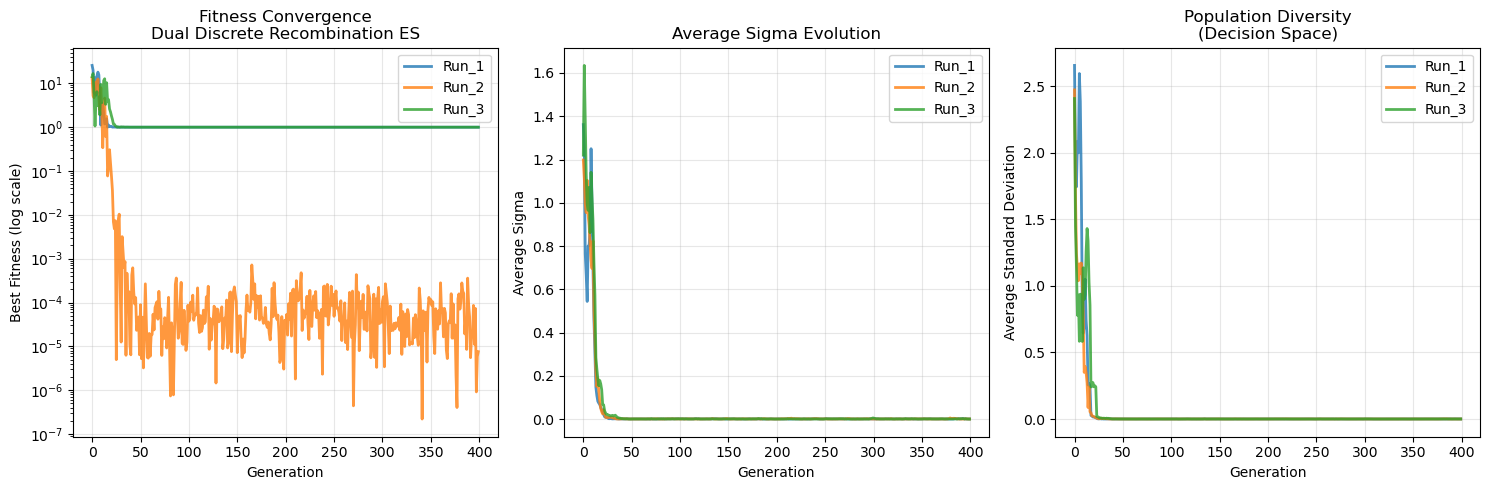

Problem 6 completed successfully!


In [31]:
# Problem 6: Extend ES with dual discrete recombination on decision variables plus individual sigmas

class DualDiscreteRecombinationES:
    """
    Evolution Strategy with:
    - Dual discrete recombination on decision variables
    - Individual sigma values with global intermediate recombination
    - Advanced recombination strategy combining multiple operators
    """
    def __init__(self, mu, lambda_val, sigma_init=1.0, bounds=(-5.12, 5.12)):
        self.mu = mu
        self.lambda_val = lambda_val
        self.bounds = bounds
        self.sigma_init = sigma_init
        
        # Self-adaptation parameters
        self.tau = 1.0 / np.sqrt(2 * np.sqrt(2))
        self.tau0 = 1.0 / np.sqrt(2 * 2)
        
    def initialize_population(self):
        """Initialize population with individual sigmas"""
        population = []
        for _ in range(self.mu):
            individual = np.random.uniform(self.bounds[0], self.bounds[1], 2)
            sigmas = np.full(2, self.sigma_init)
            fitness = rastrigin_vector(individual)
            population.append((individual.copy(), sigmas.copy(), fitness))
        
        return sorted(population, key=lambda x: x[2])
    
    def dual_discrete_recombination_decision_vars(self, population):
        """
        Dual discrete recombination on decision variables:
        For each dimension, randomly select value from one of two randomly chosen parents
        """
        recombined_individual = np.zeros(2)
        
        for dim in range(2):
            # Select two different random parents
            parent1_idx = np.random.randint(0, self.mu)
            parent2_idx = np.random.randint(0, self.mu)
            
            # Ensure different parents (if possible)
            while parent2_idx == parent1_idx and self.mu > 1:
                parent2_idx = np.random.randint(0, self.mu)
            
            # Randomly choose value from one of the two parents for this dimension
            if np.random.random() < 0.5:
                recombined_individual[dim] = population[parent1_idx][0][dim]
            else:
                recombined_individual[dim] = population[parent2_idx][0][dim]
        
        return recombined_individual
    
    def global_intermediate_recombination_sigma(self, population):
        """Global intermediate recombination for sigma values"""
        all_sigmas = np.array([ind[1] for ind in population])
        return np.mean(all_sigmas, axis=0)
    
    def mutate(self, individual, sigma):
        """Mutate individual with self-adapted sigma"""
        # Self-adapt sigma
        global_factor = self.tau0 * np.random.normal()
        individual_factors = self.tau * np.random.normal(size=2)
        
        new_sigma = sigma * np.exp(global_factor + individual_factors)
        new_sigma = np.clip(new_sigma, 0.001, 2.0)
        
        # Mutate individual
        child = individual + np.random.normal(0, new_sigma, 2)
        child = np.clip(child, self.bounds[0], self.bounds[1])
        
        return child, new_sigma
    
    def run(self, generations=500, verbose=False):
        """Execute ES with dual discrete recombination and individual sigmas"""
        population = self.initialize_population()
        
        fitness_history = []
        avg_sigma_history = []
        diversity_history = []
        
        for gen in range(generations):
            # Step 1: Recombination on sigma (global intermediate)
            recombined_sigma = self.global_intermediate_recombination_sigma(population)
            
            # Step 2: Generate lambda offspring
            offspring = []
            
            for _ in range(self.lambda_val):
                # Dual discrete recombination on decision variables
                recombined_individual = self.dual_discrete_recombination_decision_vars(population)
                
                # Mutation with recombined sigma
                child, child_sigma = self.mutate(recombined_individual, recombined_sigma)
                child_fitness = rastrigin_vector(child)
                offspring.append((child, child_sigma, child_fitness))
            
            # Step 3: (μ, λ) Selection
            offspring.sort(key=lambda x: x[2])
            population = offspring[:self.mu]
            
            # Track progress
            best_fitness = population[0][2]
            fitness_history.append(best_fitness)
            
            # Calculate statistics
            all_sigmas = np.array([ind[1] for ind in population])
            avg_sigma = np.mean(all_sigmas)
            
            # Calculate population diversity in decision space
            all_positions = np.array([ind[0] for ind in population])
            diversity = np.mean(np.std(all_positions, axis=0))
            
            avg_sigma_history.append(avg_sigma)
            diversity_history.append(diversity)
            
            if verbose and gen % 50 == 0:
                print(f"Gen {gen:3d}: Best fitness = {best_fitness:8.6f}, "
                      f"Avg sigma = {avg_sigma:.4f}, Population diversity = {diversity:.4f}")
        
        best_individual, best_sigmas, best_fitness = population[0]
        return ((best_individual, best_sigmas, best_fitness), 
                fitness_history, avg_sigma_history, diversity_history)

print("Problem 6: ES with Dual Discrete Recombination + Individual Sigmas")
print("=" * 68)

print("Dual Discrete Recombination Strategy:")
print("- Decision variables: For each dimension, randomly select from 2 random parents")
print("- Sigma values: Global intermediate recombination (mean of all parents)")
print("- Combines exploration (discrete recombination) with exploitation (sigma adaptation)")
print()

# Test Dual Discrete Recombination ES
print("Testing Dual Discrete Recombination ES (5, 20) with 3 runs:")
print("Run | Best Fitness | Solution (x1, x2)     | Final Sigmas (σ1, σ2)")
print("-" * 70)

results_problem6 = {}

for run_id in range(3):
    np.random.seed(run_id * 400 + 200)
    
    es = DualDiscreteRecombinationES(mu=5, lambda_val=20, sigma_init=1.0)
    ((best_solution, best_sigmas, best_fitness), 
     fitness_history, sigma_history, diversity_history) = es.run(generations=400)
    
    results_problem6[f'Run_{run_id+1}'] = {
        'best_solution': best_solution,
        'best_sigmas': best_sigmas,
        'best_fitness': best_fitness,
        'fitness_history': fitness_history,
        'avg_sigma_history': sigma_history,
        'diversity_history': diversity_history
    }
    
    print(f"{run_id+1:3d} | {best_fitness:11.6f} | [{best_solution[0]:6.3f}, {best_solution[1]:6.3f}] | "
          f"[{best_sigmas[0]:5.3f}, {best_sigmas[1]:5.3f}]")

# Analysis
all_best_fitness = [data['best_fitness'] for data in results_problem6.values()]
print(f"\nPerformance Summary:")
print(f"Mean best fitness: {np.mean(all_best_fitness):8.6f}")
print(f"Best overall:      {np.min(all_best_fitness):8.6f}")

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for run_name, data in results_problem6.items():
    plt.semilogy(data['fitness_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Fitness Convergence\nDual Discrete Recombination ES')
plt.xlabel('Generation')
plt.ylabel('Best Fitness (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
for run_name, data in results_problem6.items():
    plt.plot(data['avg_sigma_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Average Sigma Evolution')
plt.xlabel('Generation')
plt.ylabel('Average Sigma')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
for run_name, data in results_problem6.items():
    plt.plot(data['diversity_history'], label=run_name, alpha=0.8, linewidth=2)
plt.title('Population Diversity\n(Decision Space)')
plt.xlabel('Generation')
plt.ylabel('Average Standard Deviation')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Problem 6 completed successfully!")

Problem 7: Comprehensive Results Analysis and Reporting
Step 1: Collecting and organizing all experimental results...
Total experimental runs collected: 23
Algorithms tested: 7
Problems solved: 5

Step 2: Results saved to 'evolution_strategies_results.csv'

Step 3: Statistical Summary by Algorithm
Algorithm Performance Summary:
--------------------------------------------------------------------------------

(1,7)-ES:
  Runs: 3
  Best Fitness: 12.515719 ± 11.293421
  Best Overall: 2.322840
  Distance to Optimum: 1.9722 ± 0.9400
  Final Sigma: nan ± nan

(10,30)-ES:
  Runs: 3
  Best Fitness: 7.618069 ± 4.281363
  Best Overall: 3.551501
  Distance to Optimum: 1.5216 ± 0.5604
  Final Sigma: nan ± nan

(5,20)-ES:
  Runs: 3
  Best Fitness: 1.854764 ± 1.122988
  Best Overall: 0.964340
  Distance to Optimum: 0.8602 ± 0.7183
  Final Sigma: nan ± nan

Dual Discrete Recomb ES:
  Runs: 3
  Best Fitness: 0.663315 ± 0.574441
  Best Overall: 0.000008
  Distance to Optimum: 0.6632 ± 0.5742
  Final Si

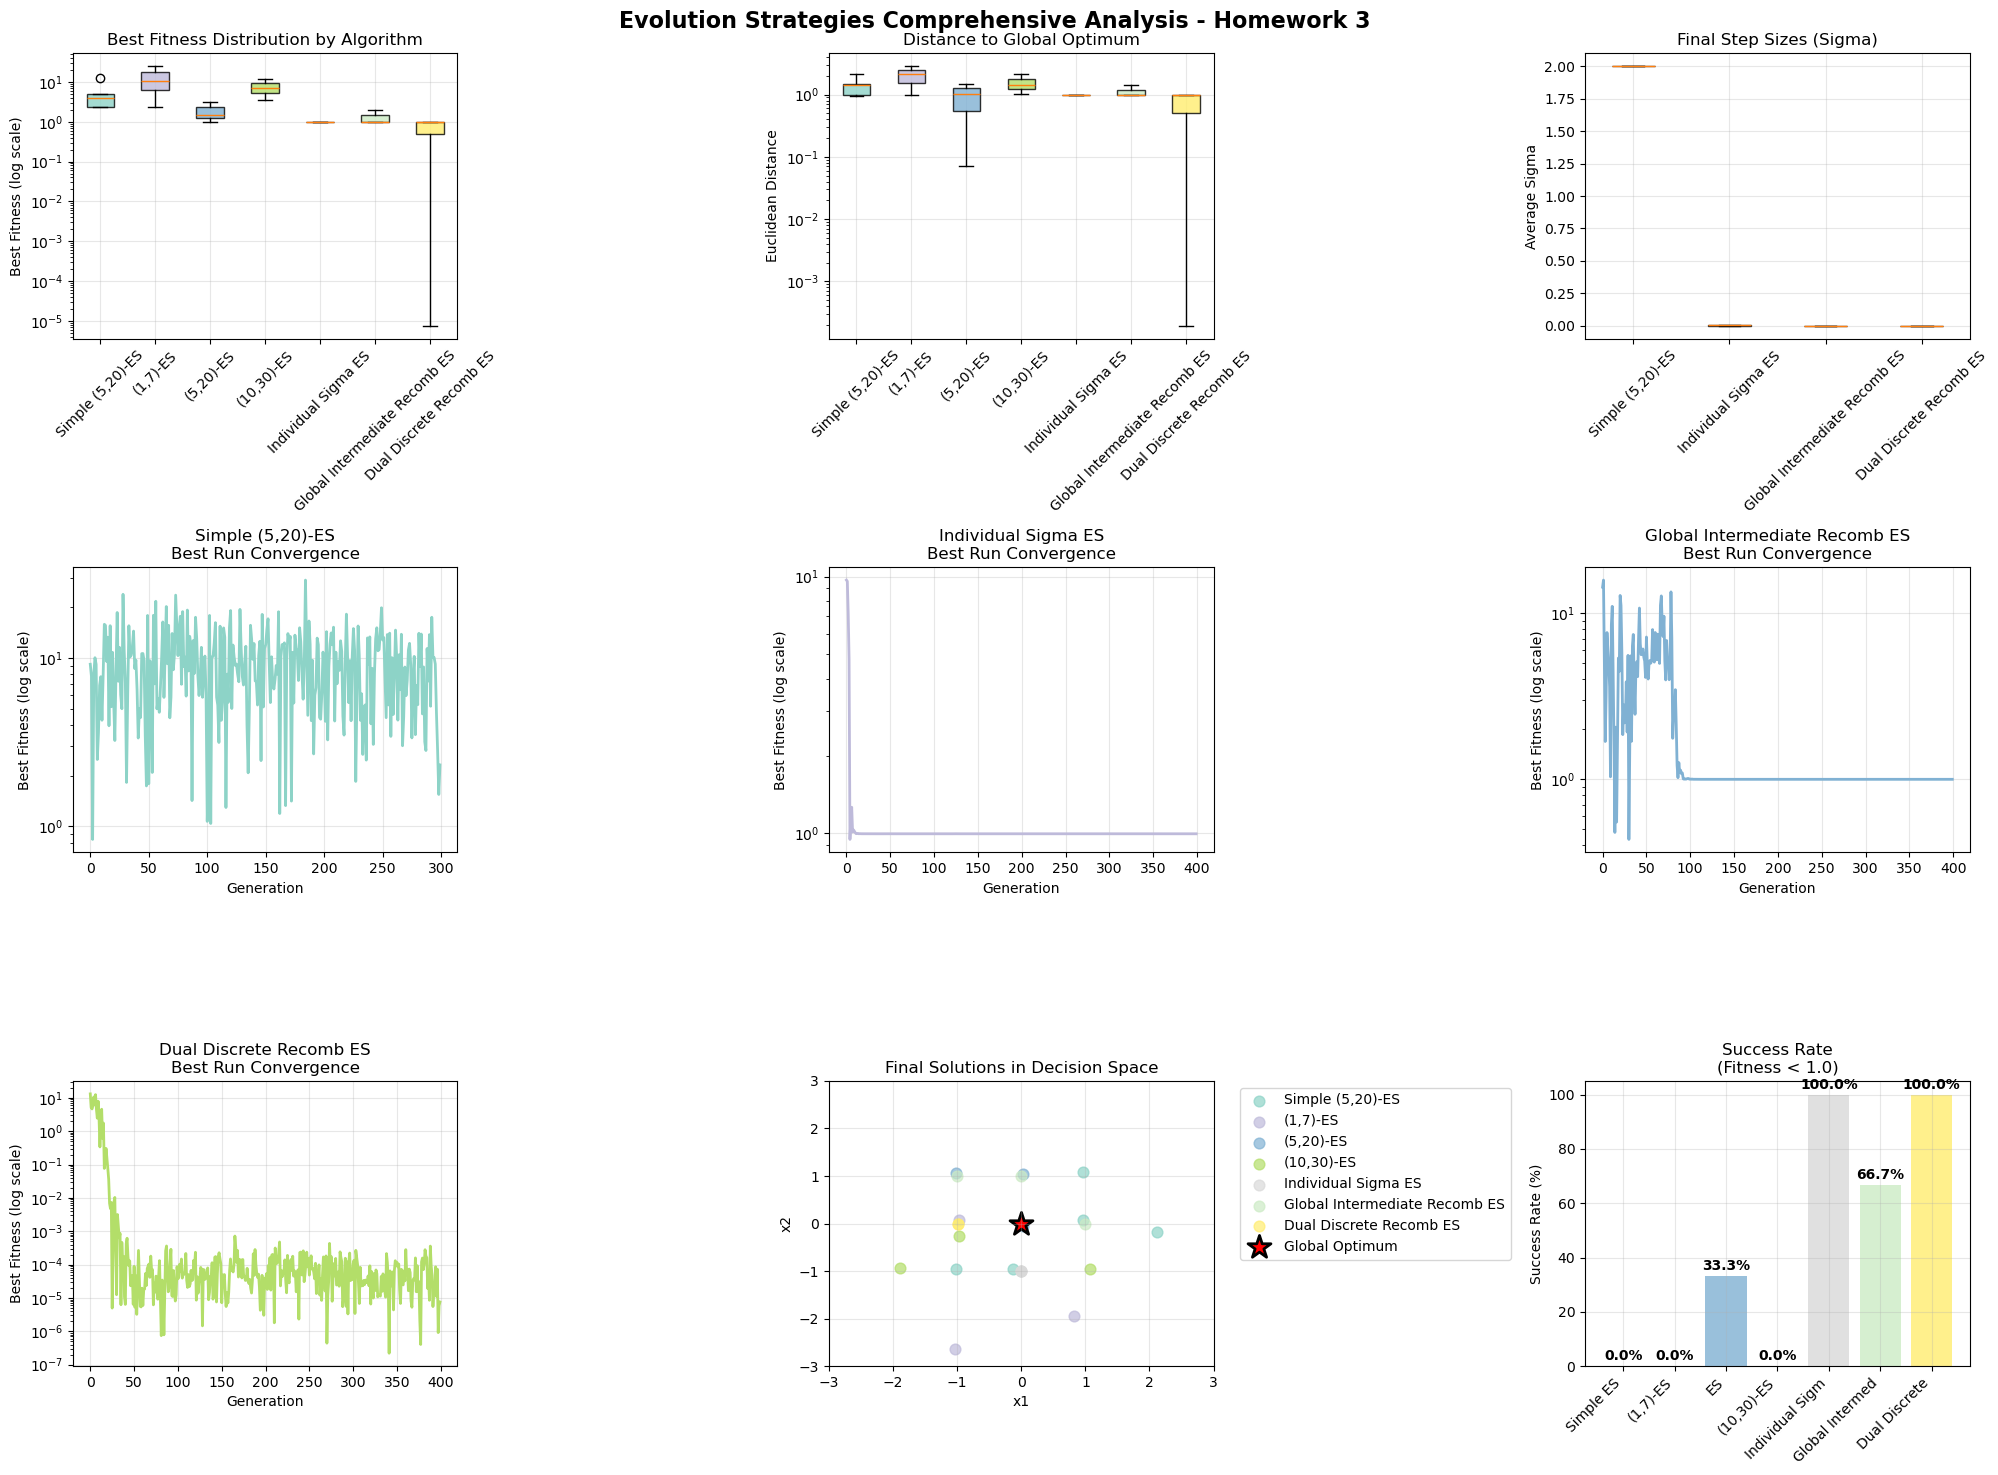


Step 5: Algorithm Ranking and Recommendations
Algorithm Ranking (Best to Worst):
----------------------------------------
1. Dual Discrete Recomb ES
   Mean Fitness: 0.663315
   Best Fitness: 0.000008
   Composite Score: 0.464307

2. Individual Sigma ES
   Mean Fitness: 0.995019
   Best Fitness: 0.994966
   Composite Score: 0.995049

3. Global Intermediate Recomb ES
   Mean Fitness: 1.326760
   Best Fitness: 0.995077
   Composite Score: 1.188420

4. (5,20)-ES
   Mean Fitness: 1.854764
   Best Fitness: 0.964340
   Composite Score: 1.388725

5. Simple (5,20)-ES
   Mean Fitness: 5.256460
   Best Fitness: 2.318540
   Composite Score: 3.599992

6. (10,30)-ES
   Mean Fitness: 7.618069
   Best Fitness: 3.551501
   Composite Score: 5.178812

7. (1,7)-ES
   Mean Fitness: 12.515719
   Best Fitness: 2.322840
   Composite Score: 7.349151

Experimental Summary:
• Total runs executed: 23
• Best overall fitness achieved: 0.000008
• Best solution: [0.0002, 0.0001]
• Achieved by: Dual Discrete Recomb 

In [35]:
# Problem 7: Collect results into DataFrame, save as CSV, and generate comprehensive analysis

print("Problem 7: Comprehensive Results Analysis and Reporting")
print("=" * 60)

# Collect all results from previous problems into a structured format
print("Step 1: Collecting and organizing all experimental results...")

all_results_data = []

# Helper function to add results to the collection
def add_results_to_collection(results_dict, algorithm_name, problem_number):
    for run_name, data in results_dict.items():
        result_entry = {
            'Problem': f'Problem_{problem_number}',
            'Algorithm': algorithm_name,
            'Run': run_name,
            'Best_Fitness': data['best_fitness'],
            'Best_X1': data['best_solution'][0],
            'Best_X2': data['best_solution'][1],
            'Distance_to_Optimum': np.sqrt(data['best_solution'][0]**2 + data['best_solution'][1]**2)
        }
        
        # Add sigma information if available
        if 'best_sigmas' in data:
            result_entry['Final_Sigma1'] = data['best_sigmas'][0]
            result_entry['Final_Sigma2'] = data['best_sigmas'][1]
            result_entry['Avg_Final_Sigma'] = np.mean(data['best_sigmas'])
        elif 'final_sigma' in data:
            result_entry['Final_Sigma1'] = data['final_sigma']
            result_entry['Final_Sigma2'] = data['final_sigma']
            result_entry['Avg_Final_Sigma'] = data['final_sigma']
        else:
            result_entry['Final_Sigma1'] = np.nan
            result_entry['Final_Sigma2'] = np.nan
            result_entry['Avg_Final_Sigma'] = np.nan
        
        all_results_data.append(result_entry)

# Add Problem 2 results
add_results_to_collection(results_problem2, 'Simple (5,20)-ES', 2)

# Add Problem 3 results
for config_name, config_results in results_problem3.items():
    add_results_to_collection(config_results, config_name, 3)

# Add Problem 4 results
add_results_to_collection(results_problem4, 'Individual Sigma ES', 4)

# Add Problem 5 results
add_results_to_collection(results_problem5, 'Global Intermediate Recomb ES', 5)

# Add Problem 6 results
add_results_to_collection(results_problem6, 'Dual Discrete Recomb ES', 6)

# Create comprehensive DataFrame
results_df = pd.DataFrame(all_results_data)

print(f"Total experimental runs collected: {len(results_df)}")
print(f"Algorithms tested: {results_df['Algorithm'].nunique()}")
print(f"Problems solved: {results_df['Problem'].nunique()}")

# Step 2: Save results to CSV
csv_filename = 'evolution_strategies_results.csv'
results_df.to_csv(csv_filename, index=False)
print(f"\nStep 2: Results saved to '{csv_filename}'")

# Step 3: Generate summary statistics
print("\nStep 3: Statistical Summary by Algorithm")
print("=" * 50)

summary_stats = results_df.groupby('Algorithm').agg({
    'Best_Fitness': ['count', 'mean', 'std', 'min', 'max'],
    'Distance_to_Optimum': ['mean', 'std', 'min'],
    'Avg_Final_Sigma': ['mean', 'std']
}).round(6)

# Flatten column names
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats = summary_stats.reset_index()

print("Algorithm Performance Summary:")
print("-" * 80)
for _, row in summary_stats.iterrows():
    print(f"\n{row['Algorithm']}:")
    print(f"  Runs: {int(row['Best_Fitness_count'])}")
    print(f"  Best Fitness: {row['Best_Fitness_mean']:.6f} ± {row['Best_Fitness_std']:.6f}")
    print(f"  Best Overall: {row['Best_Fitness_min']:.6f}")
    print(f"  Distance to Optimum: {row['Distance_to_Optimum_mean']:.4f} ± {row['Distance_to_Optimum_std']:.4f}")
    print(f"  Final Sigma: {row['Avg_Final_Sigma_mean']:.4f} ± {row['Avg_Final_Sigma_std']:.4f}")

# Step 4: Generate comprehensive visualizations
print("\nStep 4: Generating comprehensive analysis plots...")

# Create a large figure with multiple subplots
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Evolution Strategies Comprehensive Analysis - Homework 3', fontsize=16, fontweight='bold')

# Plot 1: Best fitness comparison (box plot)
ax1 = axes[0, 0]
algorithms = results_df['Algorithm'].unique()
fitness_data = [results_df[results_df['Algorithm'] == alg]['Best_Fitness'].values for alg in algorithms]
box_plot = ax1.boxplot(fitness_data, labels=algorithms, patch_artist=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(algorithms)))
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_title('Best Fitness Distribution by Algorithm')
ax1.set_ylabel('Best Fitness (log scale)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Distance to optimum
ax2 = axes[0, 1]
distance_data = [results_df[results_df['Algorithm'] == alg]['Distance_to_Optimum'].values for alg in algorithms]
box_plot2 = ax2.boxplot(distance_data, labels=algorithms, patch_artist=True)
for patch, color in zip(box_plot2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_title('Distance to Global Optimum')
ax2.set_ylabel('Euclidean Distance')
ax2.set_yscale('log')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Plot 3: Final sigma values
ax3 = axes[0, 2]
sigma_data = [results_df[results_df['Algorithm'] == alg]['Avg_Final_Sigma'].dropna().values for alg in algorithms]
sigma_labels = [alg for alg, data in zip(algorithms, sigma_data) if len(data) > 0]
sigma_data = [data for data in sigma_data if len(data) > 0]
if sigma_data:
    box_plot3 = ax3.boxplot(sigma_data, labels=sigma_labels, patch_artist=True)
    for patch, color in zip(box_plot3['boxes'], colors[:len(sigma_data)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
ax3.set_title('Final Step Sizes (Sigma)')
ax3.set_ylabel('Average Sigma')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)

# Plot 4-6: Convergence plots for best runs from each major variant
convergence_data = {
    'Simple (5,20)-ES': results_problem2,
    'Individual Sigma ES': results_problem4,
    'Global Intermediate Recomb ES': results_problem5,
    'Dual Discrete Recomb ES': results_problem6
}

plot_positions = [(1, 0), (1, 1), (1, 2), (2, 0)]
for i, (alg_name, alg_results) in enumerate(convergence_data.items()):
    if i < len(plot_positions):
        ax = axes[plot_positions[i]]
        
        # Find best run
        best_run = min(alg_results.keys(), key=lambda k: alg_results[k]['best_fitness'])
        fitness_history = alg_results[best_run]['fitness_history']
        
        ax.semilogy(fitness_history, linewidth=2, color=colors[i % len(colors)])
        ax.set_title(f'{alg_name}\nBest Run Convergence')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Best Fitness (log scale)')
        ax.grid(True, alpha=0.3)

# Plot 7: Solution space visualization
ax7 = axes[2, 1]
for i, alg in enumerate(algorithms):
    alg_data = results_df[results_df['Algorithm'] == alg]
    ax7.scatter(alg_data['Best_X1'], alg_data['Best_X2'], 
               alpha=0.7, s=60, c=[colors[i % len(colors)]], label=alg)

ax7.scatter(0, 0, s=300, c='red', marker='*', label='Global Optimum', edgecolor='black', linewidth=2)
ax7.set_title('Final Solutions in Decision Space')
ax7.set_xlabel('x1')
ax7.set_ylabel('x2')
ax7.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax7.grid(True, alpha=0.3)
ax7.set_xlim(-3, 3)
ax7.set_ylim(-3, 3)

# Plot 8: Success rate analysis
ax8 = axes[2, 2]
success_threshold = 1.0  # Consider fitness < 1.0 as successful
success_rates = []
alg_names_short = []

for alg in algorithms:
    alg_data = results_df[results_df['Algorithm'] == alg]
    success_rate = (alg_data['Best_Fitness'] < success_threshold).mean() * 100
    success_rates.append(success_rate)
    # Shorten algorithm names for display
    short_name = alg.replace(' ES', '').replace('(5,20)-', '').replace(' Recomb', '')[:15]
    alg_names_short.append(short_name)

bars = ax8.bar(range(len(success_rates)), success_rates, color=colors[:len(success_rates)], alpha=0.8)
ax8.set_title(f'Success Rate\n(Fitness < {success_threshold})')
ax8.set_ylabel('Success Rate (%)')
ax8.set_xticks(range(len(alg_names_short)))
ax8.set_xticklabels(alg_names_short, rotation=45, ha='right')
ax8.grid(True, alpha=0.3)

# Add value labels on bars
for bar, rate in zip(bars, success_rates):
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Step 5: Generate ranking and recommendations
print("\nStep 5: Algorithm Ranking and Recommendations")
print("=" * 50)

# Rank algorithms by multiple criteria
ranking_criteria = results_df.groupby('Algorithm').agg({
    'Best_Fitness': ['mean', 'min'],
    'Distance_to_Optimum': 'mean'
}).round(6)

ranking_criteria.columns = ['Mean_Fitness', 'Best_Fitness', 'Mean_Distance']
ranking_criteria = ranking_criteria.reset_index()

# Calculate composite score (lower is better)
ranking_criteria['Composite_Score'] = (
    ranking_criteria['Mean_Fitness'] * 0.5 +
    ranking_criteria['Best_Fitness'] * 0.3 +
    ranking_criteria['Mean_Distance'] * 0.2
)

# Sort by composite score
ranking_criteria = ranking_criteria.sort_values('Composite_Score')

print("Algorithm Ranking (Best to Worst):")
print("-" * 40)
for rank, (_, row) in enumerate(ranking_criteria.iterrows(), 1):
    print(f"{rank}. {row['Algorithm']}")
    print(f"   Mean Fitness: {row['Mean_Fitness']:.6f}")
    print(f"   Best Fitness: {row['Best_Fitness']:.6f}")
    print(f"   Composite Score: {row['Composite_Score']:.6f}")
    print()

# Final summary
print("Experimental Summary:")
print("=" * 30)
print(f"• Total runs executed: {len(results_df)}")
print(f"• Best overall fitness achieved: {results_df['Best_Fitness'].min():.6f}")
best_solution_row = results_df.loc[results_df['Best_Fitness'].idxmin()]
print(f"• Best solution: [{best_solution_row['Best_X1']:.4f}, {best_solution_row['Best_X2']:.4f}]")
print(f"• Achieved by: {best_solution_row['Algorithm']} ({best_solution_row['Run']})")
print(f"• Distance to global optimum: {best_solution_row['Distance_to_Optimum']:.6f}")

print(f"\nResults successfully saved to '{csv_filename}'")
print("Problem 7 completed successfully!")

print("\n" + "="*80)

print("="*80)